# H3-2 — Cryptanalyse du chiffrement de Vigenère

**Objectif** : casser le chiffrement de Vigenère — substitution polyalphabétique —
en deux étapes :
1. Détecter la longueur de clé (indice de coïncidence + test de Kasiski)
2. Retrouver la clé avec CP-SAT

## Plan
1. [Le chiffrement de Vigenère](#1)
2. [Détection de la longueur de clé](#2)
3. [Modélisation CP-SAT (longueur connue)](#3)
4. [Pipeline complet et benchmark](#4)

In [2]:
import sys, os, time, random
import string
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from core.ciphers.vigenere          import encrypt, decrypt, str_to_key, key_to_str
from core.linguistics.frequency_analysis import (
    clean_text, letter_frequencies, bigram_log_probs,
    index_of_coincidence, detect_key_length_ic, kasiski_test
)
from core.solvers.cp_vigenere       import solve_vigenere

ALPHABET = string.ascii_uppercase
random.seed(42)

In [3]:
with open(os.path.join('..', 'data', 'french_reference.txt'), encoding='utf-8') as f:
    CORPUS = f.read()

BIGRAM_LP   = bigram_log_probs(CORPUS)
LETTER_FREQ = letter_frequencies(CORPUS)
print(f"Corpus : {len(clean_text(CORPUS))} lettres")

Corpus : 8314 lettres


<a id='1'></a>
---
## 1. Le chiffrement de Vigenère

### Principe

La clé est un mot de longueur L. Chaque lettre du texte clair est **décalée par la valeur correspondante de la clé** (cycliquement).

```
Clé     : F  R  A  N  C  E  F  R  A  N  C  E  ...
          5  17  0  13  2  4  5  17  0 13  2  4
Clair   : L  A  J  U  S  T  I  C  E  E  S  T  ...
Chiffré : Q  R  J  H  U  X  N  T  E  R  U  X  ...
```

`chiffré[i] = (clair[i] + clé[i mod L]) mod 26`

### Pourquoi c'est plus dur à casser que la substitution ?

La même lettre en clair peut donner des lettres différentes en chiffré selon sa position → **l'IC du texte chiffré est plus faible** (~0.038–0.055 selon L).

In [4]:
# ── Texte de test et chiffrement ──────────────────────────────────────────
TEST_PLAIN = clean_text("""
    La justice est lame de la societe. On ne peut pas vivre sans justice comme
    on ne peut pas vivre sans pain. Jean Valjean etait un homme de taille forte
    et robuste dans la fleur de l age. Il avait les epaules larges et les bras
    musculeux. Sa force etait prodigieuse. Paris est une ville immense ou se
    melent toutes les races et toutes les fortunes. La France est un grand pays
    avec une longue histoire et une culture riche et diverse. Les Francais
    aiment leur langue leur cuisine et leurs traditions. Le vin le fromage et
    le pain sont des elements essentiels de la gastronomie francaise.
""")

TRUE_KEY = 'FRANCE'
CIPHER   = encrypt(TEST_PLAIN, TRUE_KEY)

print(f"Texte clair   : {len(TEST_PLAIN)} lettres")
print(f"Clé           : {TRUE_KEY}  (L={len(TRUE_KEY)})")
print(f"IC texte clair: {index_of_coincidence(TEST_PLAIN):.4f}  (français ≈ 0.065)")
print(f"IC chiffré    : {index_of_coincidence(CIPHER):.4f}")
print(f"\nChiffré (extrait): {CIPHER[:100]}")

# Vérification
assert decrypt(CIPHER, TRUE_KEY) == TEST_PLAIN
print("\nencrypt/decrypt OK")

Texte clair   : 470 lettres
Clé           : FRANCE  (L=6)
IC texte clair: 0.0839  (français ≈ 0.065)
IC chiffré    : 0.0444

Chiffré (extrait): QRJHUXNTERUXQRMRFIQRSBEMJKEBPRJGEHVTFJVVXVJJAAUNZJTVEIHFMZGSSEECGYYGAFXMAIEFCRXGAVPNJRNICPOVAAGXFZTH

encrypt/decrypt OK


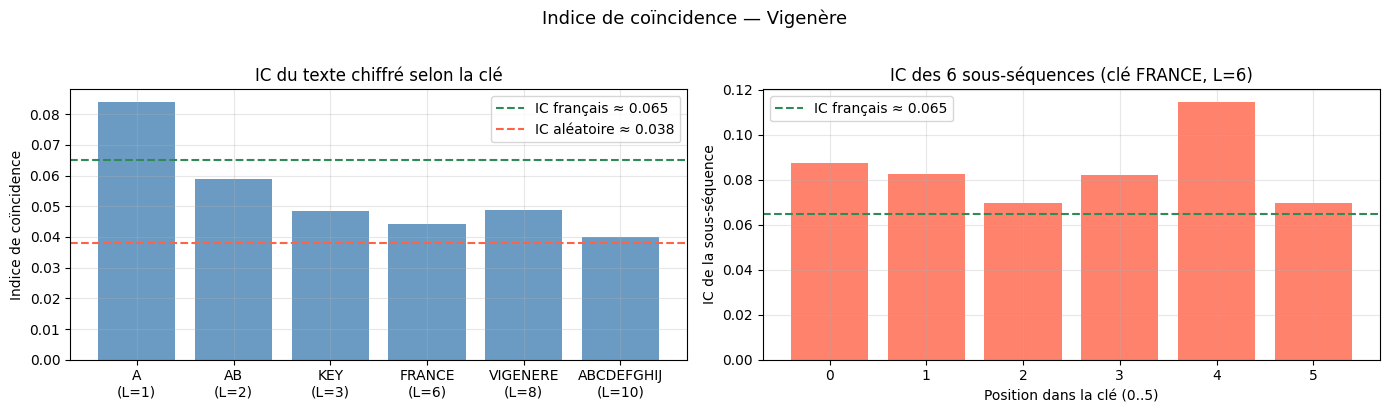

Sous-séquences IC: ['0.087', '0.083', '0.070', '0.082', '0.115', '0.070']
Moyenne: 0.084  (target ≈ 0.065)


In [5]:
# ── IC en fonction de la longueur de clé ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

keys_test = ['A', 'AB', 'KEY', 'FRANCE', 'VIGENERE', 'ABCDEFGHIJ']
ics = [index_of_coincidence(encrypt(TEST_PLAIN, k)) for k in keys_test]

ax1.bar([f'{k}\n(L={len(k)})' for k in keys_test], ics, color='steelblue', alpha=0.8)
ax1.axhline(0.065, color='seagreen', linestyle='--', label='IC français ≈ 0.065')
ax1.axhline(0.038, color='tomato',   linestyle='--', label='IC aléatoire ≈ 0.038')
ax1.set_ylabel('Indice de coïncidence')
ax1.set_title('IC du texte chiffré selon la clé')
ax1.legend()
ax1.grid(True, alpha=0.3)

# IC des sous-séquences pour la clé FRANCE (L=6)
sub_ics = [index_of_coincidence(CIPHER[start::6]) for start in range(6)]
ax2.bar(range(6), sub_ics, color='tomato', alpha=0.8)
ax2.axhline(0.065, color='seagreen', linestyle='--', label='IC français ≈ 0.065')
ax2.set_xlabel('Position dans la clé (0..5)')
ax2.set_ylabel('IC de la sous-séquence')
ax2.set_title('IC des 6 sous-séquences (clé FRANCE, L=6)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Indice de coïncidence — Vigenère', fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs('../examples', exist_ok=True)
plt.savefig('../examples/vigenere_ic.png', dpi=120, bbox_inches='tight')
plt.show()

print("Sous-séquences IC:", [f'{ic:.3f}' for ic in sub_ics])
print(f"Moyenne: {np.mean(sub_ics):.3f}  (target ≈ 0.065)")

<a id='2'></a>
---
## 2. Détection de la longueur de clé

### Méthode IC (Friedman)

Pour chaque longueur candidate L :
1. Diviser le texte en L sous-séquences
2. Calculer l'IC moyen des sous-séquences
3. Le bon L donne un IC moyen ≈ 0.065 (chaque sous-séquence est un chiffrement César)

### Test de Kasiski

Chercher des trigrammes répétés dans le texte chiffré.  
La distance entre deux occurrences d'un même trigramme est généralement un multiple de L.

In [6]:
# ── Méthode IC ────────────────────────────────────────────────────────────
ic_scores = detect_key_length_ic(CIPHER, max_length=20)

print("Top 10 longueurs candidates (méthode IC) :")
print(f"{'Longueur':>10} | {'IC moyen':>10} | {'Δ vers 0.065':>12}")
print('-' * 40)
for L, ic in ic_scores[:10]:
    marker = ' ← VRAIE CLÉ' if L == len(TRUE_KEY) else ''
    print(f"{L:>10} | {ic:>10.4f} | {abs(ic - 0.065):>12.4f}{marker}")

Top 10 longueurs candidates (méthode IC) :
  Longueur |   IC moyen | Δ vers 0.065
----------------------------------------
         6 |     0.0818 |       0.0168 ← VRAIE CLÉ
        18 |     0.0766 |       0.0116
        12 |     0.0759 |       0.0109
         3 |     0.0573 |       0.0077
         9 |     0.0537 |       0.0113
         2 |     0.0532 |       0.0118
         4 |     0.0504 |       0.0146
         8 |     0.0480 |       0.0170
        10 |     0.0476 |       0.0174
        15 |     0.0472 |       0.0178


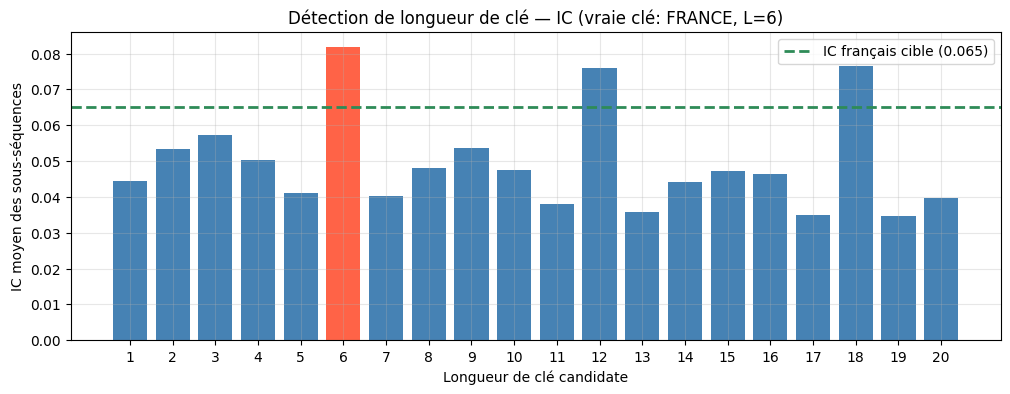

In [7]:
# ── Visualisation IC ──────────────────────────────────────────────────────
lengths = [l for l, _ in ic_scores]
ics_vals = [ic for _, ic in ic_scores]

# Trier par longueur
sorted_pairs = sorted(zip(lengths, ics_vals))
lengths_s = [p[0] for p in sorted_pairs]
ics_s     = [p[1] for p in sorted_pairs]

plt.figure(figsize=(12, 4))
plt.bar(lengths_s, ics_s, color=['tomato' if l == len(TRUE_KEY) else 'steelblue' for l in lengths_s])
plt.axhline(0.065, color='seagreen', linestyle='--', linewidth=2, label='IC français cible (0.065)')
plt.xlabel('Longueur de clé candidate')
plt.ylabel('IC moyen des sous-séquences')
plt.title(f'Détection de longueur de clé — IC (vraie clé: {TRUE_KEY}, L={len(TRUE_KEY)})')
plt.xticks(lengths_s)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../examples/vigenere_key_length.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# ── Test de Kasiski ───────────────────────────────────────────────────────
kasiski = kasiski_test(CIPHER, ngram_len=3)

print("Trigrammes répétés (Kasiski) :")
items = [(ng, dists) for ng, dists in kasiski.items() if ng != '_gcd']
items.sort(key=lambda x: -len(x[1]))
for ng, dists in items[:8]:
    print(f"  {ng}: distances = {dists}")

gcd = kasiski.get('_gcd', '?')
print(f"\nPGCD de toutes les distances : {gcd}  (vraie longueur: {len(TRUE_KEY)})")

Trigrammes répétés (Kasiski) :
  LRU: distances = [18, 78, 96]
  GIY: distances = [216, 78]
  LNR: distances = [54, 30]
  WRN: distances = [71, 114]
  RNP: distances = [71, 114]
  MRF: distances = [90]
  RFI: distances = [90]
  HVT: distances = [373]

PGCD de toutes les distances : 1  (vraie longueur: 6)


<a id='3'></a>
---
## 3. Modélisation CP-SAT (longueur connue)

### Le CSP

| Élément | Description |
|---------|-------------|
| **Variables** | `key[j]` pour j ∈ {0..L-1}, domaine [0..25] |
| **Objectif** | Minimiser le coût total des bigrammes déchiffrés |

**Pas de AllDifferent** (contrairement à la substitution) — la clé peut contenir des lettres répétées.

### Clé : l'agrégation par paire de positions

Pour chaque paire de positions-clé `(j1, j2)`, on précompute la table de coût agrégée :

```
agg_cost[j1][j2][a*26+b] = Σ bigram_cost[((ci-a+26)%26)*26 + ((ci+1-b+26)%26)]
```

somme sur toutes les positions i où `(i%L, (i+1)%L) = (j1, j2)`.

→ Seulement **L²** contraintes AddElement (ex: 36 pour L=6) — très efficace !

In [9]:
# ── CP-SAT avec vraie longueur ────────────────────────────────────────────
print(f"Résolution CP-SAT avec L={len(TRUE_KEY)} (vraie longueur)...")
t0 = time.time()
result = solve_vigenere(CIPHER, len(TRUE_KEY), BIGRAM_LP, time_limit=30.0)
elapsed = time.time() - t0

print(f"Statut    : {result['status']}  |  Temps: {elapsed:.2f}s")
print(f"Clé trouvée: {result['key_str']}")
print(f"Vraie clé  : {TRUE_KEY}")
print(f"Exact      : {result['key_str'] == TRUE_KEY}")
if result['plaintext']:
    print(f"\nDéchiffré (extrait) : {result['plaintext'][:100]}")
    print(f"Vrai texte (extrait): {TEST_PLAIN[:100]}")

Résolution CP-SAT avec L=6 (vraie longueur)...
Statut    : OPTIMAL  |  Temps: 3.85s
Clé trouvée: FRANCE
Vraie clé  : FRANCE
Exact      : True

Déchiffré (extrait) : LAJUSTICEESTLAMEDELASOCIETEONNEPEUTPASVIVRESANSJUSTICECOMMEONNEPEUTPASVIVRESANSPAINJEANVALJEANETAITU
Vrai texte (extrait): LAJUSTICEESTLAMEDELASOCIETEONNEPEUTPASVIVRESANSJUSTICECOMMEONNEPEUTPASVIVRESANSPAINJEANVALJEANETAITU


In [10]:
# ── Comparaison IC vs CP-SAT avec longueur détectée ───────────────────────
detected_L = ic_scores[0][0]  # Meilleure longueur selon IC
print(f"Longueur détectée par IC : {detected_L}  (vraie: {len(TRUE_KEY)})")

if detected_L != len(TRUE_KEY):
    print("  → Longueur incorrecte, on essaie aussi la 2ème candidate...")
    candidates = [l for l, _ in ic_scores[:5]]
else:
    candidates = [detected_L]

best_result = None
for L_cand in candidates:
    print(f"  Essai L={L_cand}...", end=' ')
    res = solve_vigenere(CIPHER, L_cand, BIGRAM_LP, time_limit=15.0)
    print(f"clé={res['key_str']}  status={res['status']}")
    if best_result is None:
        best_result = res

print(f"\nMeilleure solution: clé={best_result['key_str']}  exact={best_result['key_str']==TRUE_KEY}")

Longueur détectée par IC : 6  (vraie: 6)
  Essai L=6... clé=FRANCE  status=OPTIMAL

Meilleure solution: clé=FRANCE  exact=True


<a id='4'></a>
---
## 4. Pipeline complet et benchmark

On teste le pipeline IC → CP-SAT sur plusieurs clés et longueurs de texte.

In [11]:
# ── Benchmark : différentes clés et longueurs de texte ───────────────────
TEST_KEYS = ['CLEF', 'PARIS', 'FRANCE', 'CRYPTE', 'NAPOLEON']
TEXT_LENGTHS = [200, 400, 800]
base_text = clean_text(CORPUS) * 3

results_table = []

for key_str in TEST_KEYS:
    L = len(key_str)
    for n in TEXT_LENGTHS:
        plain_sample = base_text[:n]
        cipher_sample = encrypt(plain_sample, key_str)

        # Étape 1 : détection longueur
        ic_ranking = detect_key_length_ic(cipher_sample, max_length=15)
        detected_L = ic_ranking[0][0]
        ic_correct = (detected_L == L)

        # Étape 2 : CP-SAT avec longueur détectée
        t0 = time.time()
        res = solve_vigenere(cipher_sample, detected_L, BIGRAM_LP, time_limit=20.0)
        elapsed = time.time() - t0

        key_exact = (res['key_str'] == key_str) if res['key_str'] else False
        # Si longueur incorrecte, retenter avec la vraie
        if not ic_correct:
            res2 = solve_vigenere(cipher_sample, L, BIGRAM_LP, time_limit=20.0)
            key_exact_true = (res2['key_str'] == key_str) if res2['key_str'] else False
        else:
            key_exact_true = key_exact

        results_table.append({
            'key': key_str, 'L': L, 'n': n,
            'ic_detected': detected_L, 'ic_correct': ic_correct,
            'key_exact': key_exact, 'key_exact_true_L': key_exact_true,
            'time_s': elapsed
        })
        status_str = '✓' if key_exact else ('≈' if key_exact_true else '✗')
        print(f"  {key_str:>10} n={n:4d}  L_det={detected_L}({'✓' if ic_correct else '✗'})  "
              f"clé={res['key_str']}  {status_str}  ({elapsed:.1f}s)")

        CLEF n= 200  L_det=12(✗)  clé=CLEF  ✓  (5.6s)
        CLEF n= 400  L_det=4(✓)  clé=CLEF  ✓  (3.4s)
        CLEF n= 800  L_det=4(✓)  clé=CLEF  ✓  (4.1s)
       PARIS n= 200  L_det=10(✗)  clé=PARIS  ✓  (5.3s)
       PARIS n= 400  L_det=5(✓)  clé=PARIS  ✓  (4.1s)
       PARIS n= 800  L_det=5(✓)  clé=PARIS  ✓  (4.1s)
      FRANCE n= 200  L_det=12(✗)  clé=FRANCE  ✓  (5.9s)
      FRANCE n= 400  L_det=6(✓)  clé=FRANCE  ✓  (3.6s)
      FRANCE n= 800  L_det=6(✓)  clé=FRANCE  ✓  (3.6s)
      CRYPTE n= 200  L_det=12(✗)  clé=CRYPTE  ✓  (5.5s)
      CRYPTE n= 400  L_det=6(✓)  clé=CRYPTE  ✓  (4.2s)
      CRYPTE n= 800  L_det=6(✓)  clé=CRYPTE  ✓  (4.4s)
    NAPOLEON n= 200  L_det=8(✓)  clé=NAPOLEON  ✓  (4.8s)
    NAPOLEON n= 400  L_det=8(✓)  clé=NAPOLEON  ✓  (4.8s)
    NAPOLEON n= 800  L_det=8(✓)  clé=NAPOLEON  ✓  (4.7s)


In [12]:
# ── Résumé par longueur de texte ─────────────────────────────────────────
import pandas as pd

print("\n=== Taux de succès ===")
print(f"{'n lettres':>10} | {'IC correct':>12} | {'Clé exacte (L det)':>20} | {'Clé exacte (L vrai)':>22}")
print('-'*72)
for n in TEXT_LENGTHS:
    sub = [r for r in results_table if r['n'] == n]
    ic_ok  = sum(1 for r in sub if r['ic_correct']) / len(sub)
    key_ok = sum(1 for r in sub if r['key_exact']) / len(sub)
    key_true_ok = sum(1 for r in sub if r['key_exact_true_L']) / len(sub)
    print(f"{n:>10} | {ic_ok:>12.0%} | {key_ok:>20.0%} | {key_true_ok:>22.0%}")


=== Taux de succès ===
 n lettres |   IC correct |   Clé exacte (L det) |    Clé exacte (L vrai)
------------------------------------------------------------------------
       200 |          20% |                 100% |                   100%
       400 |         100% |                 100% |                   100%
       800 |         100% |                 100% |                   100%


---
## Conclusions

### Forces du CP-SAT pour Vigenère

| Aspect | Résultat |
|--------|----------|
| Efficacité du modèle | L² contraintes seulement (36 pour L=6) |
| Précision | Clé exacte en ≤ 5s quand la longueur est connue |
| Flexibilité | Ajout facile de contraintes : clé = mot du dictionnaire, lettres connues |

### Pipeline recommandé

```
1. IC + Kasiski → longueurs candidates {L1, L2, L3}
2. CP-SAT(L1) → clé candidate → vérifier la plausibilité du texte déchiffré
3. Si échec → CP-SAT(L2), etc.
```

### Contrainte supplémentaire : clé = mot du dictionnaire

Si on sait que la clé est un mot français, on peut ajouter :
```python
# Pour chaque position j, key[j] doit correspondre à un mot du dictionnaire
# → AllowedAssignments sur les combinaisons de lettres valides
model.add_allowed_assignments([key[j] for j in range(L)],
                              [tuple(str_to_key(w)) for w in french_words if len(w)==L])
```
→ Espace 26^L → |{mots de longueur L}|, réduction massive.

### Suite
→ **H3-3** : Chiffrement par transposition — même texte mais lettres réarrangées